In [ ]:
import torch as t
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_regression

In [ ]:
fv,cv=make_regression(n_samples=1000,n_features=1,n_informative=1,bias=0.5)

In [ ]:
fv.shape

(1000, 1)

<Axes: >

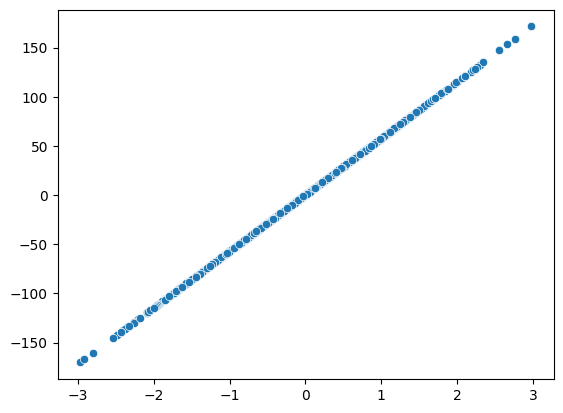

In [ ]:
sns.scatterplot(x=fv[:,0],y=cv)

In [ ]:
import numpy as np

In [ ]:

fv=np.arange(-1,1,0.001).reshape(-1,1)
cv=np.square(fv)

In [ ]:
fv.shape

(2000, 1)

In [ ]:
sns.scatterplot(x=fv,y=cv)

ValueError: Per-column arrays must each be 1-dimensional

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(fv,cv,test_size=0.2)
x_trainf,x_cv,y_trainf,y_cv=train_test_split(x_train,y_train,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()

In [ ]:
x_trains=st.fit_transform(x_trainf)
x_cvs=st.transform(x_cv)
x_tests=st.transform(x_test)

In [ ]:
x_trains=t.from_numpy(x_trains).to(dtype=t.float32)
y_train=t.from_numpy(y_trainf).to(dtype=t.float32)

x_cvs=t.from_numpy(x_cvs).to(dtype=t.float32)
y_cv=t.from_numpy(y_cv).to(dtype=t.float32)

x_tests=t.from_numpy(x_tests).to(dtype=t.float32)
y_test=t.from_numpy(y_test).to(dtype=t.float32)

In [ ]:
class SimpleLinearRegression(t.nn.Module):
  def __init__(self,n_features):
    super().__init__()

    self.ann=t.nn.Sequential(
        t.nn.Linear(n_features,3),
        t.nn.ReLU(),
        t.nn.Linear(3,2),
        t.nn.ReLU(),
        t.nn.Linear(2,1),

    )

  def forward(self,data):
    return self.ann(data)

In [ ]:
y_train.shape

torch.Size([1280, 1])

In [ ]:
model=SimpleLinearRegression(1)

# define the loss

loss=t.nn.MSELoss()

# define the optimiser
opt=t.optim.SGD(model.parameters(),lr=0.1)

train_loss_d=[]
cv_loss_d=[]

for iter in range(3000):
  model.train()

  predi_t=model(x_trains)

  train_loss=loss(predi_t.squeeze(),y_train.squeeze())

  opt.zero_grad()

  train_loss.backward()

  opt.step()

  model.eval()

  with t.no_grad():
    predi_cv=model(x_cvs)

    cv_loss=loss(predi_cv,y_cv)

  train_loss_d.append(train_loss.detach().numpy())
  cv_loss_d.append(cv_loss.numpy())

  print("epochs :{}, train_loss :{}, cv_loss :{}".format(iter+1,train_loss,cv_loss))


epochs :1, train_loss :0.38049739599227905, cv_loss :0.22572048008441925
epochs :2, train_loss :0.2076607644557953, cv_loss :0.14821268618106842
epochs :3, train_loss :0.13670390844345093, cv_loss :0.11211159080266953
epochs :4, train_loss :0.10494248569011688, cv_loss :0.09421134740114212
epochs :5, train_loss :0.08997559547424316, cv_loss :0.08488316833972931
epochs :6, train_loss :0.08264245092868805, cv_loss :0.08078397065401077
epochs :7, train_loss :0.07970862090587616, cv_loss :0.07810886949300766
epochs :8, train_loss :0.07762613147497177, cv_loss :0.07680810987949371
epochs :9, train_loss :0.07660983502864838, cv_loss :0.0747598186135292
epochs :10, train_loss :0.07522739470005035, cv_loss :0.07399499416351318
epochs :11, train_loss :0.07453639805316925, cv_loss :0.07257944345474243
epochs :12, train_loss :0.07356534153223038, cv_loss :0.07177998125553131
epochs :13, train_loss :0.07299724966287613, cv_loss :0.07116927951574326
epochs :14, train_loss :0.07232324779033661, cv_l

In [ ]:
x_tests

tensor([[-1.3546],
        [-0.2256],
        [-1.6954],
        [ 0.5850],
        [ 1.2493],
        [-0.0139],
        [ 0.5953],
        [ 0.0342],
        [ 1.3594],
        [ 0.0687],
        [ 1.5315],
        [ 0.2580],
        [ 1.4523],
        [ 0.9085],
        [ 0.6831],
        [-1.6145],
        [ 0.2786],
        [-0.6163],
        [-0.9966],
        [ 1.3715],
        [-0.2205],
        [-1.0758],
        [-1.0534],
        [ 0.3423],
        [-1.2634],
        [-1.3529],
        [-1.2600],
        [ 0.4714],
        [-0.3065],
        [-1.6627],
        [-1.1928],
        [-1.2892],
        [-0.1637],
        [ 0.4662],
        [-1.0345],
        [-1.3374],
        [ 0.2700],
        [-0.4889],
        [-1.0552],
        [ 0.0962],
        [-1.3391],
        [ 1.3181],
        [ 1.4644],
        [-1.4183],
        [-1.6386],
        [ 0.0050],
        [ 1.6382],
        [ 1.6141],
        [ 0.2683],
        [-1.2393],
        [ 1.5350],
        [ 0.4232],
        [ 1.

In [ ]:
with t.no_grad():
  predi=model(x_tests)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [ ]:
mean_absolute_error(y_test,predi.squeeze().numpy())

0.02663356624543667

In [ ]:
mean_squared_error(y_test,predi.squeeze().numpy())

0.0009728759760037065

In [ ]:
r2_score(y_test,predi.squeeze().numpy())

0.9889334440231323